<a href="https://colab.research.google.com/github/raeyaanmuppaneni/EMG-controlled-robotic-arm/blob/main/Testing_the_best_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
#load the model
import pickle
model_name  = "/content/drive/MyDrive/Raeyaan shared folder/Exoskeleton Project/models/randomForest_model_19_7.pkl"
# model_name = "/content/drive/MyDrive/Raeyaan shared folder/Exoskeleton Project/models/randomForest_envelop_best_model.pkl"
file_name = open(model_name, 'rb')
final_model = pickle.load(file_name)
print("Model is loaded")

Model is loaded


In [ ]:
import pandas as pd
#read the data file
#test_data = pd.read_csv("/content/drive/MyDrive/Technology and Trainings/Python and AI/Raeyaan/Raeyaan shared folder/Exoskeleton Project/Dataset/Raeyaan Dataset/raw_emg_test.csv")
test_data = pd.read_csv("/content/drive/MyDrive/Raeyaan shared folder/Exoskeleton Project/Dataset/Raeyaan Dataset/raw_EMG_test_20_7.csv")
test_data.head()

,exo_project_emg_1_emg_envelop_0,exo_project_emg_1_emg_envelop_1,exo_project_emg_1_emg_envelop_2,exo_project_emg_1_emg_envelop_3,exo_project_emg_1_emg_envelop_4,exo_project_emg_1_emg_envelop_5,exo_project_emg_1_emg_envelop_6,exo_project_emg_1_emg_envelop_7,exo_project_emg_1_emg_envelop_8,exo_project_emg_1_emg_envelop_9,...,exo_project_emg_1_emg_envelop_51,exo_project_emg_1_emg_envelop_52,exo_project_emg_1_emg_envelop_53,exo_project_emg_1_emg_envelop_54,exo_project_emg_1_emg_envelop_55,exo_project_emg_1_emg_envelop_56,exo_project_emg_1_emg_envelop_57,exo_project_emg_1_emg_envelop_58,exo_project_emg_1_emg_envelop_59,Folder
0,124,122,126,124,124,124,126,122,120,120,...,112,112,114,114,114,116,118,120,124,Hand Lift
1,100,100,100,100,100,100,100,100,98,100,...,96,96,96,96,98,96,98,98,98,Normal
2,478,476,474,470,470,464,462,458,454,452,...,476,478,478,478,478,478,480,480,478,Wrist Lift
3,142,140,140,140,138,138,136,134,134,134,...,166,168,170,172,172,172,172,174,176,Wrist Lift
4,360,360,360,358,354,350,344,340,332,328,...,462,456,454,456,454,458,454,458,452,Wrist Lift


In [ ]:
#label count
test_data["Folder"].value_counts()

,count
Folder,
Hand Lift,14
Normal,14
Wrist Lift,14
Hand Twist,14


In [ ]:
#labels encoding
#first saved labels for confusion matrix axis
labels = test_data["Folder"].unique()
labels.sort()
print(labels)

#then encode the labels
test_data['Folder'] = pd.factorize(test_data['Folder'], sort = True)[0]

['Hand Lift' 'Hand Twist' 'Normal' 'Wrist Lift']


In [ ]:
import numpy as np

#separating the true labels for the evaluations
y_true = np.array(test_data['Folder'].to_list())

In [ ]:
#getting predictions data
test_data_list = test_data.iloc[:,:-1].values

y_pred = []
y_pred_proba = []

for row_data in test_data_list:
  predictions = final_model.predict(np.array([row_data]))
  pred_proba = final_model.predict_proba(np.array([row_data]))
  y_pred.append(predictions[0])
  y_pred_proba.append(pred_proba)

print("Predictions: {}".format(y_pred))

Predictions: [np.int64(2), np.int64(2), np.int64(3), np.int64(0), np.int64(3), np.int64(3), np.int64(3), np.int64(1), np.int64(0), np.int64(1), np.int64(2), np.int64(0), np.int64(3), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(3), np.int64(0), np.int64(0), np.int64(1), np.int64(2), np.int64(1), np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(0), np.int64(1), np.int64(0), np.int64(2), np.int64(2), np.int64(0), np.int64(0), np.int64(2), np.int64(2), np.int64(3), np.int64(2), np.int64(1), np.int64(3), np.int64(0), np.int64(0), np.int64(0), np.int64(3), np.int64(1), np.int64(2), np.int64(0), np.int64(2), np.int64(3), np.int64(0), np.int64(3), np.int64(1)]


In [ ]:
# setting the predictions
pred_proba = np.array([pred_array[0] for pred_array in y_pred_proba])

In [ ]:
#evaluation function

def model_evaluations(y_true, y_pred, y_pred_proba):
  import matplotlib.pyplot as plt
  import seaborn as sns
  from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score
  from sklearn.metrics import roc_auc_score

  acc_score = accuracy_score(y_true, y_pred)
  print("Accuracy score: {}\n".format(acc_score))

  print("Classification Report: {}".format(classification_report(y_true, y_pred)))

  plt.figure(figsize = (6,6))
  sns.heatmap(confusion_matrix(y_true, y_pred), annot = True, annot_kws={"size": 24}, fmt="g", cmap = "Blues", xticklabels = labels, yticklabels = labels)
  plt.xticks(ha="right",rotation=45)
  plt.yticks(va="top",rotation=45)
  plt.title("Consfuion Matrix")
  plt.show()

  return classification_report(y_true, y_pred, output_dict = True)


Accuracy score: 0.7857142857142857

Classification Report:               precision    recall  f1-score   support

           0       0.57      0.57      0.57        14
           1       1.00      0.93      0.96        14
           2       0.93      0.93      0.93        14
           3       0.67      0.71      0.69        14

    accuracy                           0.79        56
   macro avg       0.79      0.79      0.79        56
weighted avg       0.79      0.79      0.79        56



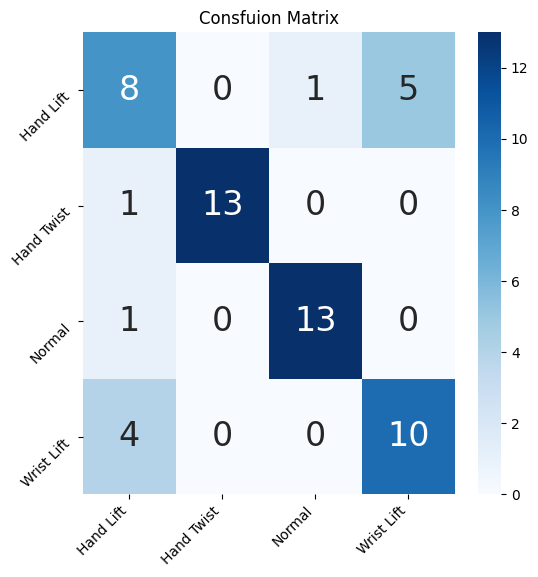

In [ ]:
#getting evaulations
report = model_evaluations(y_true, y_pred, pred_proba)

In [ ]:
#save the report as dataframe and set the indexes
report_df = pd.DataFrame(report).transpose()
labels_list = list(labels)
labels_list.extend(["accuracy","macro avg", "weighted avg"])
print(labels_list)

['Bird cherry-oat aphid', 'Cerodonta Denticornis', 'English grain aphid', 'Green bug', 'Longlegged spider mite', 'Penthaleus major', 'Wheat blossom midge', 'Wheat phloeothrips', 'Wheat sawfly', 'accuracy', 'macro avg', 'weighted avg']


In [ ]:
#save the dataframe
report_df["Labels"] = labels_list
report_df.set_index("Labels")
report_df.to_csv("/content/drive/MyDrive/1:1_Anika_Bhat/Results/mlp_test_report.csv", index = False)